### Import + Helper

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent # go up from notebooks/
sys.path.append(str(ROOT))

In [2]:
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

from src.config import Config
from src.data import make_loaders, load_rdata_xy_names
from src.transformation import make_transform
from src.utils import set_seed
from models.cvae import CVAE

### loss / eval / training

In [3]:
def elbo_loss(x, x_hat, mu, logvar, beta: float):
    recon = ((x_hat - x) ** 2).sum(dim=1).mean()
    kl = (-0.5 * (1.0 + logvar - mu**2 - torch.exp(logvar)).sum(dim=1)).mean()
    total = recon + beta * kl
    return total, recon, kl


@torch.no_grad()
def evaluate(model, loader, device, beta: float, decoder_noise: float = 0.0):
    model.eval()
    tot = rec = kl = 0.0
    n = 0

    for x, c in loader:
        x, c = x.to(device), c.to(device)
        x_hat, mu, logvar = model(x, c)

        if decoder_noise > 0:
            x_hat = x_hat + decoder_noise * torch.randn_like(x_hat)

        loss, r, k = elbo_loss(x, x_hat, mu, logvar, beta)
        tot += loss.item()
        rec += r.item()
        kl += k.item()
        n += 1

    return {
        "loss": tot / n,
        "recon": rec / n,
        "kl": kl / n,
    }


def train_cvae_from_arrays(X, y, cfg: Config, seed: int = 42):
    set_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, val_loader, scaler = make_loaders(
        X,
        y,
        test_size=cfg.test_size,
        batch_size=cfg.batch_size,
        seed=seed,
        x_transform=cfg.x_transform,
    )

    model = CVAE(
        x_dim=X.shape[1],
        c_dim=2,
        z_dim=cfg.z_dim,
        hidden=cfg.hidden,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    best_val = float("inf")
    best_state = None

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        tot = rec = kl = 0.0
        n = 0

        for x_batch, c_batch in train_loader:
            x_batch, c_batch = x_batch.to(device), c_batch.to(device)
            opt.zero_grad(set_to_none=True)

            x_hat, mu, logvar = model(x_batch, c_batch)

            if cfg.decoder_noise > 0:
                x_hat = x_hat + cfg.decoder_noise * torch.randn_like(x_hat)

            loss, r, k = elbo_loss(x_batch, x_hat, mu, logvar, beta=cfg.beta)
            loss.backward()
            opt.step()

            tot += loss.item()
            rec += r.item()
            kl += k.item()
            n += 1

        val_metrics = evaluate(
            model,
            val_loader,
            device,
            beta=cfg.beta,
            decoder_noise=cfg.decoder_noise,
        )

        if val_metrics["loss"] < best_val:
            best_val = val_metrics["loss"]
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()

    return model, scaler, device

### Sampling

In [4]:
@torch.no_grad()
def sample_class(model, n, y_label, scaler_mean, scaler_scale, transform, device):
    model = model.to(device)
    model.eval()

    z = torch.randn(n, model.z_dim, device=device)
    c = F.one_hot(
        torch.full((n,), y_label, dtype=torch.long, device=device),
        num_classes=2
    ).float()

    x_scaled = model.decode(z, c).cpu().numpy()
    x_t = x_scaled * scaler_scale + scaler_mean
    x = transform.inverse(x_t)

    return x.astype(np.float32)


def sample_both_classes(model, y_real, scaler, cfg: Config, device):
    transform = make_transform(cfg.x_transform)

    n0 = int((y_real == 0).sum())
    n1 = int((y_real == 1).sum())

    X_y0 = sample_class(
        model=model,
        n=n0,
        y_label=0,
        scaler_mean=scaler.mean_,
        scaler_scale=scaler.scale_,
        transform=transform,
        device=device,
    )

    X_y1 = sample_class(
        model=model,
        n=n1,
        y_label=1,
        scaler_mean=scaler.mean_,
        scaler_scale=scaler.scale_,
        transform=transform,
        device=device,
    )

    X_syn = np.vstack([X_y0, X_y1])
    y_syn = np.r_[np.zeros(n0, dtype=int), np.ones(n1, dtype=int)]

    return X_syn, y_syn

### RF probe for reduced data

In [5]:
def rf_auc_probe_stratified(real_X, real_y, syn_X, syn_y, seed=42, n_splits=5):
    real_y = np.asarray(real_y).astype(int)
    syn_y = np.asarray(syn_y).astype(int)

    n_neg = min((real_y == 0).sum(), (syn_y == 0).sum())
    n_pos = min((real_y == 1).sum(), (syn_y == 1).sum())

    rng = np.random.default_rng(seed)

    real_neg_i = np.where(real_y == 0)[0]
    real_pos_i = np.where(real_y == 1)[0]
    syn_neg_i = np.where(syn_y == 0)[0]
    syn_pos_i = np.where(syn_y == 1)[0]

    real_idx = np.concatenate([
        rng.choice(real_neg_i, size=n_neg, replace=False),
        rng.choice(real_pos_i, size=n_pos, replace=False)
    ])

    syn_idx = np.concatenate([
        rng.choice(syn_neg_i, size=n_neg, replace=False),
        rng.choice(syn_pos_i, size=n_pos, replace=False)
    ])

    X = np.vstack([real_X[real_idx], syn_X[syn_idx]])
    s = np.r_[np.zeros(len(real_idx), dtype=int), np.ones(len(syn_idx), dtype=int)]

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=seed,
        n_jobs=-1,
    )

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aucs = cross_val_score(rf, X, s, cv=cv, scoring="roc_auc")

    return float(aucs.mean()), float(aucs.std()), aucs

### baseline full model

In [6]:
cfg = Config()
from pathlib import Path
from src.config import Config

ROOT = Path().resolve().parent 

cfg.data_path = ROOT / "data" / "allSyntheticData.RData"
print(cfg.data_path)
print(cfg.data_path.exists())

X, y, feature_names = load_rdata_xy_names(cfg.data_path, x_key=cfg.x_key, y_key=cfg.y_key)

print(X.shape)
print(len(feature_names))

C:\Users\tonyt\MATH4600_VAE\data\allSyntheticData.RData
True
(91, 63)
63


In [7]:
full_model, full_scaler, device = train_cvae_from_arrays(X, y, cfg, seed=cfg.seed)
X_syn_full, y_syn_full = sample_both_classes(full_model, y, full_scaler, cfg, device)

baseline_auc, baseline_sd, baseline_folds = rf_auc_probe_stratified(
    X, y, X_syn_full, y_syn_full, seed=cfg.seed
)

print("Baseline LOFO reference")
print(f"AUC = {baseline_auc:.3f} ± {baseline_sd:.3f}")
print("folds =", np.round(baseline_folds, 3))

Baseline LOFO reference
AUC = 0.975 ± 0.018
folds = [0.991 0.991 0.985 0.951 0.957]


# LOFO Time
Leave-one-feauture-out

In [8]:
results = []
corr_store = {}

for j, feat in enumerate(feature_names):
    print(f"\n--- LOFO {j+1}/{len(feature_names)}: drop {feat} ---")

    keep_idx = [k for k in range(len(feature_names)) if k != j]
    keep_names = [feature_names[k] for k in keep_idx]

    X_drop = X[:, keep_idx]

    model_j, scaler_j, device_j = train_cvae_from_arrays(
        X_drop, y, cfg, seed=cfg.seed
    )

    X_syn_j, y_syn_j = sample_both_classes(
        model_j, y, scaler_j, cfg, device_j
    )

    # ----- RF probe -----
    auc_j, sd_j, folds_j = rf_auc_probe_stratified(
        X_drop, y, X_syn_j, y_syn_j, seed=cfg.seed
    )

    # ----- correlation -----
    corr_syn_j = np.corrcoef(X_syn_j, rowvar=False)
    corr_real_j = np.corrcoef(X_drop, rowvar=False)


    # store using dropped feature name
    corr_store[feat] = {
    "real": corr_real_j,
    "syn": corr_syn_j,
    "names": keep_names
}

    results.append({
        "dropped_feature": feat,
        "n_features_left": X_drop.shape[1],
        "auc_mean": auc_j,
        "auc_sd": sd_j,
        "delta_auc_from_baseline": auc_j - baseline_auc,
    })
    results_df = pd.DataFrame(results).sort_values("auc_mean")


--- LOFO 1/63: drop spikeProduction_D1D2 ---

--- LOFO 2/63: drop spikeDecay_D1D2 ---

--- LOFO 3/63: drop spikeProduction_D3 ---

--- LOFO 4/63: drop spikeDecay_D3 ---

--- LOFO 5/63: drop RBDProduction_D1D2 ---

--- LOFO 6/63: drop RBDDecay_D1D2 ---

--- LOFO 7/63: drop RBDProduction_D3 ---

--- LOFO 8/63: drop RBDDecay_D3 ---

--- LOFO 9/63: drop V1_blood_IgGspike ---

--- LOFO 10/63: drop V4_blood_IgGspike ---

--- LOFO 11/63: drop V4a_blood_IgGspike ---

--- LOFO 12/63: drop V6_blood_IgGspike ---

--- LOFO 13/63: drop V8_blood_IgGspike ---

--- LOFO 14/63: drop V8a_blood_IgGspike ---

--- LOFO 15/63: drop V8b_blood_IgGspike ---

--- LOFO 16/63: drop V9_blood_IgGspike ---

--- LOFO 17/63: drop V10_blood_IgGspike ---

--- LOFO 18/63: drop V11_blood_IgGspike ---

--- LOFO 19/63: drop V1_blood_IgGRBD ---

--- LOFO 20/63: drop V4_blood_IgGRBD ---

--- LOFO 21/63: drop V4a_blood_IgGRBD ---

--- LOFO 22/63: drop V6_blood_IgGRBD ---

--- LOFO 23/63: drop V8_blood_IgGRBD ---

--- LOFO 24/

In [9]:
corr_store.keys()

list(corr_store.keys())[:5]



['spikeProduction_D1D2',
 'spikeDecay_D1D2',
 'spikeProduction_D3',
 'spikeDecay_D3',
 'RBDProduction_D1D2']

| dropped_feature     |   n_features_left |   auc_mean |     auc_sd |   delta_auc_from_baseline |
|:--------------------|------------------:|-----------:|-----------:|--------------------------:|
| RBDDecay_D1D2       |                62 |   0.959974 | 0.0290123  |                -0.0149123 |
| V8b_Saliva_IgGspike |                62 |   0.959974 | 0.0207125  |                -0.0149123 |
| V8_Saliva_IgAspike  |                62 |   0.961404 | 0.00900841 |                -0.0134828 |
| V8_IFNg             |                62 |   0.962606 | 0.0276013  |                -0.0122807 |
| V9_IL2              |                62 |   0.962671 | 0.0192479  |                -0.0122157 |


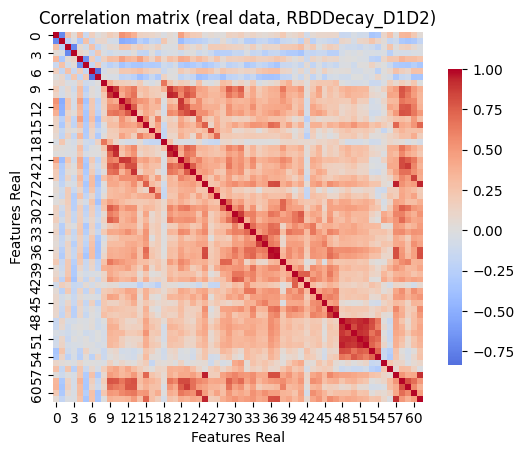

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
markdown_table = results_df.head(5).to_markdown(index=False) # index=False removes the pandas index column
print(markdown_table)
step = 2
c = corr_store["V8_IFNg"]
diff = c["real"] - c["syn"]


ax = sns.heatmap(
    corr_store["V9_IL2"]["real"],
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)


ax.set_title("Correlation matrix (real data, RBDDecay_D1D2)")
ax.set_xlabel("Features Real")
ax.set_ylabel("Features Real")

plt.show()

deltas are shrinking

# Correlation

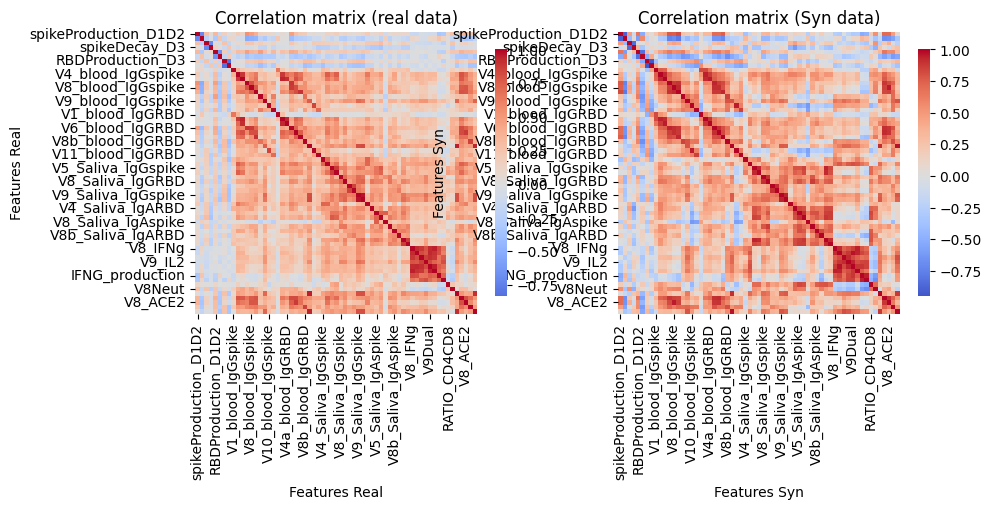

<Figure size 1000x800 with 0 Axes>

In [11]:

corr_store
step = 4  # show every 4th feature

df_real = pd.DataFrame(X, columns=feature_names)
df_syn  = pd.DataFrame(X_syn_full, columns=feature_names)

corr_real = df_real.corr()
corr_syn  = df_syn.corr()

fig, ax = plt.subplots(1, 2, figsize=(10,4))
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_real,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax[0]
)

sns.heatmap(
    corr_syn,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax[1]
)

ax[0].set_title("Correlation matrix (real data)")
ax[0].set_xlabel("Features Real")
ax[0].set_ylabel("Features Real")

ax[1].set_title("Correlation matrix (Syn data)")
ax[1].set_xlabel("Features Syn")
ax[1].set_ylabel("Features Syn")
# ax.set_xticks(np.arange(0, len(feature_names), step))
# ax.set_yticks(np.arange(0, len(feature_names), step))

# ax.set_xticklabels(feature_names[::step], rotation=90, fontsize=7)
# ax.set_yticklabels(feature_names[::step], fontsize=7)

plt.tight_layout()
plt.show()

## Keep only one feature
To see the other end of the extreme

In [12]:
single_results = []

for j, feat in enumerate(feature_names):
    print(f"\n--- Single-feature {j+1}/{len(feature_names)}: keep {feat} ---")

    X_one = X[:, [j]] 

    model_j, scaler_j, device_j = train_cvae_from_arrays(X_one, y, cfg, seed=cfg.seed)
    X_syn_j, y_syn_j = sample_both_classes(model_j, y, scaler_j, cfg, device_j)

    auc_j, sd_j, folds_j = rf_auc_probe_stratified(
        X_one, y, X_syn_j, y_syn_j, seed=cfg.seed
    )

    single_results.append({
        "kept_feature": feat,
        "n_features_kept": X_one.shape[1],
        "auc_mean": auc_j,
        "auc_sd": sd_j,
        "delta_auc_from_baseline": auc_j - baseline_auc,
    })

single_results_df = pd.DataFrame(single_results).sort_values("auc_mean")
single_results_df.head(10)


--- Single-feature 1/63: keep spikeProduction_D1D2 ---

--- Single-feature 2/63: keep spikeDecay_D1D2 ---

--- Single-feature 3/63: keep spikeProduction_D3 ---

--- Single-feature 4/63: keep spikeDecay_D3 ---

--- Single-feature 5/63: keep RBDProduction_D1D2 ---

--- Single-feature 6/63: keep RBDDecay_D1D2 ---

--- Single-feature 7/63: keep RBDProduction_D3 ---

--- Single-feature 8/63: keep RBDDecay_D3 ---

--- Single-feature 9/63: keep V1_blood_IgGspike ---

--- Single-feature 10/63: keep V4_blood_IgGspike ---

--- Single-feature 11/63: keep V4a_blood_IgGspike ---

--- Single-feature 12/63: keep V6_blood_IgGspike ---

--- Single-feature 13/63: keep V8_blood_IgGspike ---

--- Single-feature 14/63: keep V8a_blood_IgGspike ---

--- Single-feature 15/63: keep V8b_blood_IgGspike ---

--- Single-feature 16/63: keep V9_blood_IgGspike ---

--- Single-feature 17/63: keep V10_blood_IgGspike ---

--- Single-feature 18/63: keep V11_blood_IgGspike ---

--- Single-feature 19/63: keep V1_blood_IgG

,kept_feature,n_features_kept,auc_mean,auc_sd,delta_auc_from_baseline
23,V8a_blood_IgGRBD,1,0.424237,0.110214,-0.550650
2,spikeProduction_D3,1,0.462118,0.031500,-0.512768
38,V4_Saliva_IgAspike,1,0.466309,0.070789,-0.508577
9,V4_blood_IgGspike,1,0.488337,0.108505,-0.486550
10,V4a_blood_IgGspike,1,0.505637,0.078934,-0.469250
5,RBDDecay_D1D2,1,0.511712,0.054296,-0.463174
19,V4_blood_IgGRBD,1,0.531238,0.078567,-0.443648
6,RBDProduction_D3,1,0.539068,0.071182,-0.435819
8,V1_blood_IgGspike,1,0.568876,0.062002,-0.406010
1,spikeDecay_D1D2,1,0.574594,0.097325,-0.400292


In [13]:
markdown_table = single_results_df.head(5).to_markdown(index=False) # index=False removes the pandas index column
print(markdown_table)

| kept_feature       |   n_features_kept |   auc_mean |    auc_sd |   delta_auc_from_baseline |
|:-------------------|------------------:|-----------:|----------:|--------------------------:|
| V8a_blood_IgGRBD   |                 1 |   0.424237 | 0.110214  |                 -0.55065  |
| spikeProduction_D3 |                 1 |   0.462118 | 0.0314998 |                 -0.512768 |
| V4_Saliva_IgAspike |                 1 |   0.466309 | 0.0707886 |                 -0.508577 |
| V4_blood_IgGspike  |                 1 |   0.488337 | 0.108505  |                 -0.48655  |
| V4a_blood_IgGspike |                 1 |   0.505637 | 0.0789344 |                 -0.46925  |


In [14]:
single_results_df[single_results_df["kept_feature"] == "spikeProduction_D3"]

,kept_feature,n_features_kept,auc_mean,auc_sd,delta_auc_from_baseline
2,spikeProduction_D3,1,0.462118,0.0315,-0.512768


In [15]:
hard_feats = single_results_df.loc[
    single_results_df["auc_mean"] > 0.46,
    "kept_feature"
].tolist()

len(hard_feats)

62

In [16]:
feature_names_arr = np.array(feature_names)
threshhold = 0.5

# pick features to drop
hard_feats = single_results_df.loc[
    single_results_df["auc_mean"] > threshhold,
    "kept_feature"
].tolist()

# keep everything NOT in hard_feats
keep_mask = ~np.isin(feature_names_arr, hard_feats)

X_sub = X[:, keep_mask]
kept_names = feature_names_arr[keep_mask].tolist()

# train CVAE
model_hard, scaler_hard, device_hard = train_cvae_from_arrays(
    X_sub, y, cfg, seed=cfg.seed
)

# sample synthetic
X_syn_hard, y_syn_hard = sample_both_classes(
    model_hard, y, scaler_hard, cfg, device_hard
)

# RF probe
auc_hard, sd_hard, folds_hard = rf_auc_probe_stratified(
    X_sub, y, X_syn_hard, y_syn_hard, seed=cfg.seed
)

# print summary
print("Dropped:", hard_feats)
print("Kept:", kept_names)
print("AUC Threshhold: ", threshhold)
print(f"AUC = {auc_hard:.3f} ± {sd_hard:.3f}")
print("folds =", np.round(folds_hard, 3))

Dropped: ['V4a_blood_IgGspike', 'RBDDecay_D1D2', 'V4_blood_IgGRBD', 'RBDProduction_D3', 'V1_blood_IgGspike', 'spikeDecay_D1D2', 'V8_blood_IgGspike', 'V5_Saliva_IgGspike', 'V7_ACE2', 'V8_Saliva_IgAspike', 'V8_blood_IgGRBD', 'Il2_production', 'V5_Saliva_IgARBD', 'V4a_blood_IgGRBD', 'V8b_Saliva_IgARBD', 'RBDProduction_D1D2', 'RBDDecay_D3', 'V8a_blood_IgGspike', 'V8_IL2', 'V5_Saliva_IgGRBD', 'spikeDecay_D3', 'V9_Saliva_IgAspike', 'V8_Saliva_IgARBD', 'V8_Saliva_IgGRBD', 'V8b_Saliva_IgAspike', 'IFNG_production', 'V4_Saliva_IgARBD', 'V9_blood_IgGRBD', 'V4_Saliva_IgGRBD', 'V9_IFNg', 'V9_Saliva_IgARBD', 'V8b_ACE2', 'V8_Saliva_IgGspike', 'V10_blood_IgGRBD', 'V11_blood_IgGRBD', 'V9_IL2', 'spikeProduction_D1D2', 'RATIO_CD4CD8', 'V5_Saliva_IgAspike', 'V9_Saliva_IgGRBD', 'V8_IFNg', 'V9Dual', 'V6_blood_IgGspike', 'V9_Saliva_IgGspike', 'V8Dual', 'V8b_blood_IgGRBD', 'V8b_Saliva_IgGRBD', 'V9_ACE2', 'V8b_Saliva_IgGspike', 'V6_blood_IgGRBD', 'V8b_blood_IgGspike', 'V10_blood_IgGspike', 'V4_Saliva_IgGspike'